In [41]:
# importing libraries
import pandas as pd # reading csv files and datasethandling
import numpy as np # performing mathematical operations
import matplotlib.pyplot as plt # graphical visualization
import seaborn as sns # statistical graphs visualization
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # encoding
from sklearn.model_selection import train_test_split # spliting dataset into train and test
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.svm import SVC # building model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix # model evaluation

In [42]:
#loading dataset
df = pd.read_csv(r"C:\Users\rasika\Downloads\Pharma_Industry (1).csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [43]:
# Dataet summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [44]:
# Summary Statistics
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [45]:
# Checking for missing values
df.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

### Histogram for visualizing  freqequancy distribution of numerical features

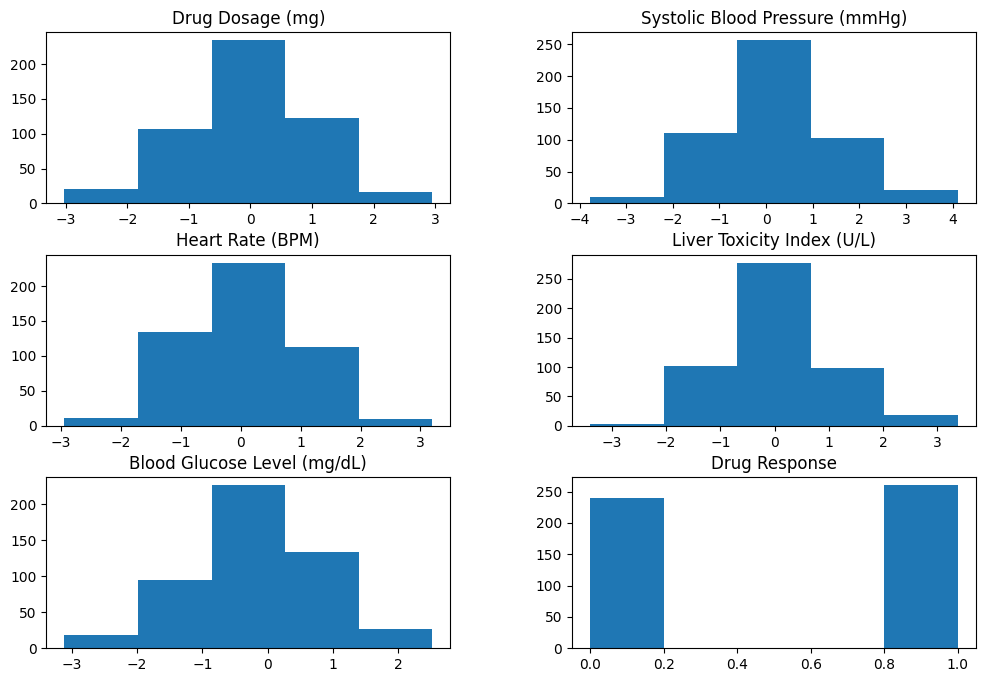

In [46]:
df.hist(bins = 5, grid = False, figsize = (12, 8))
plt.show()

#### It shows symmetric distribution of data over all the features, as it is in bell shape curve that shows normal distribution. Blood Glucose Level is approximetly normally distributed. No missing values are present in dataset. From Drug Response visualization Patient responded positively to the drug are more than Patient did not respond 

### Scatter plot to show relation among features 

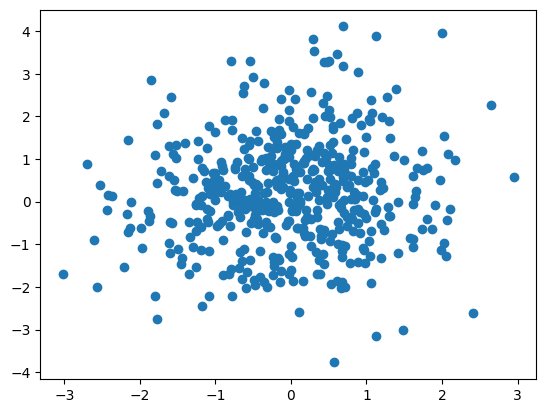

In [47]:
plt.scatter(data = df, x = 'Drug Dosage (mg)',	y = 'Systolic Blood Pressure (mmHg)')
plt.show()

#### points are scattered randomly this show these two features are not related



### PairPlot to show distribution and relation among features

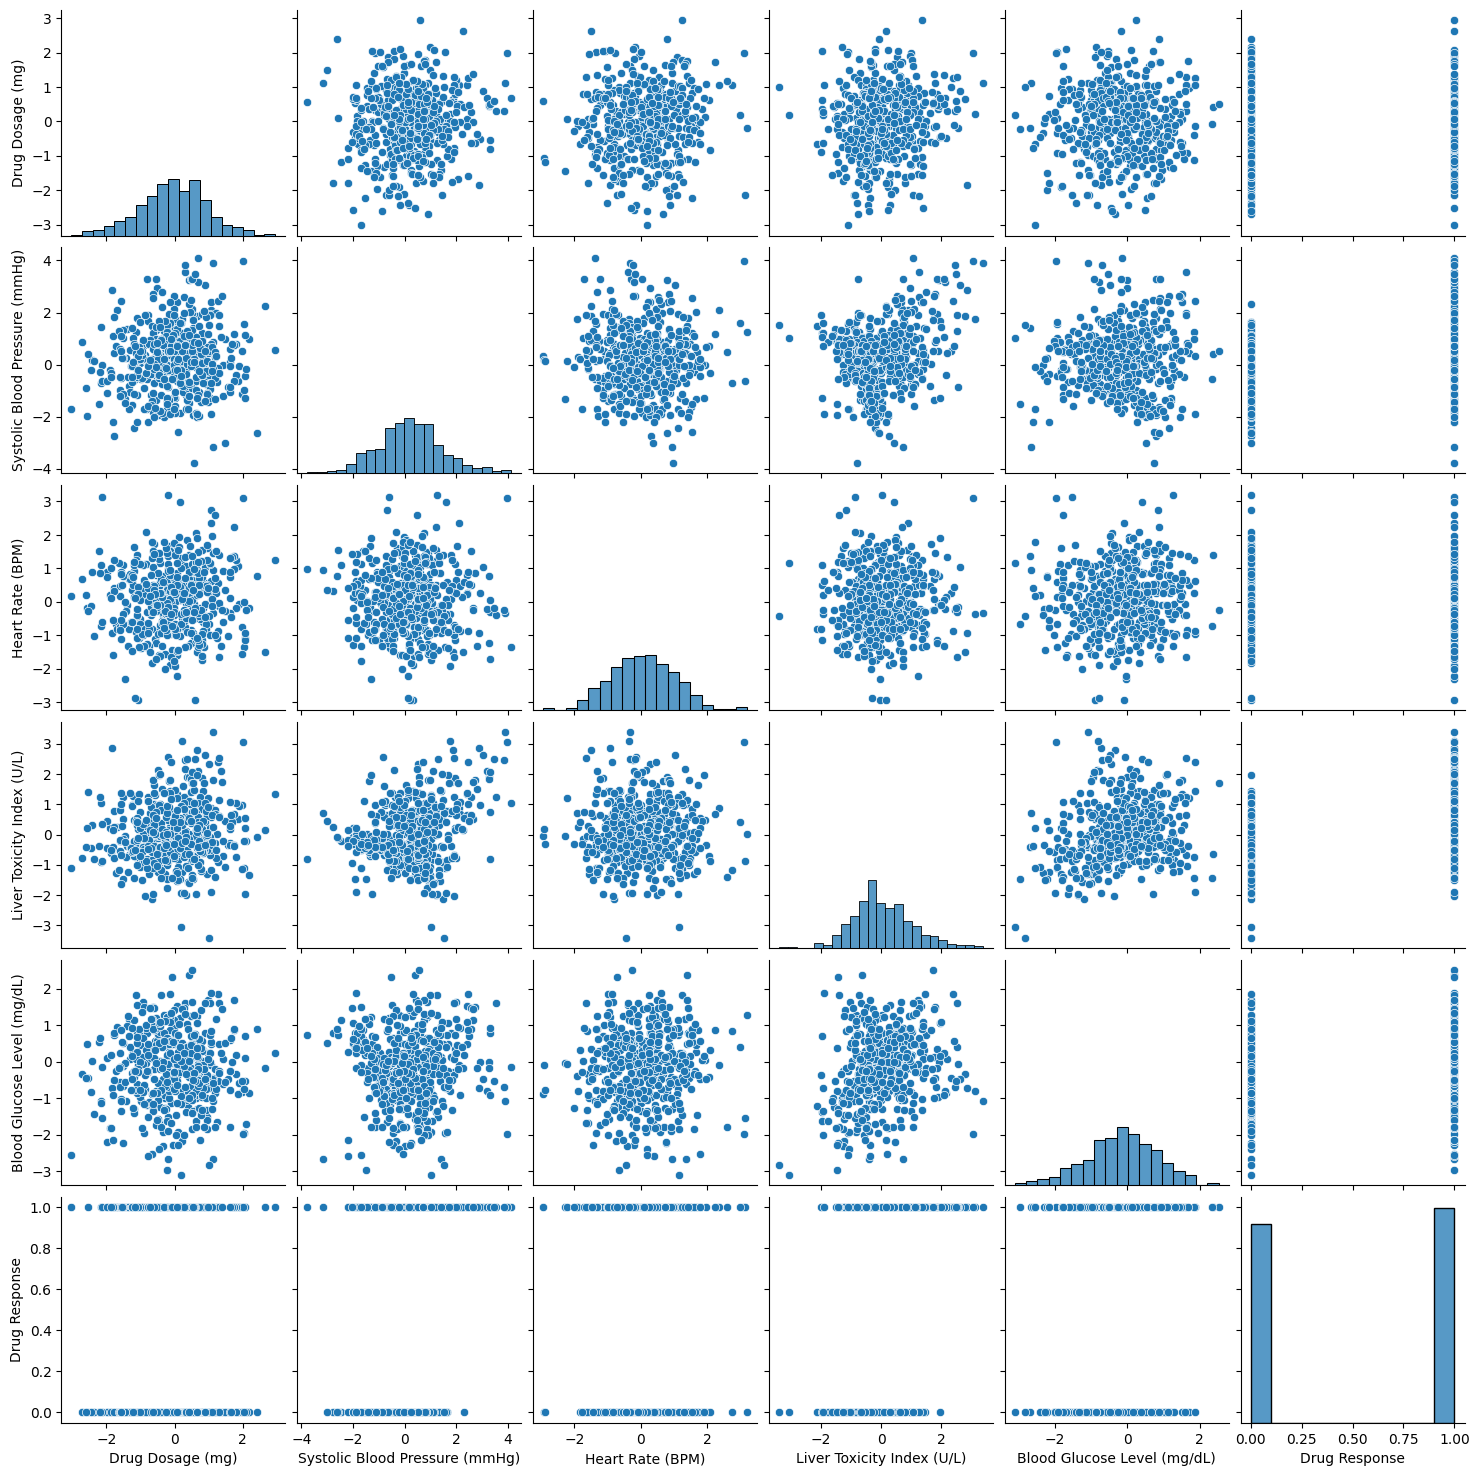

In [48]:
sns.pairplot(data = df)

#### Above pairplot visualizes that all features have data equally distributed. No features are related with each other as points in scatter plot are scattered randomly.

### Boxplot for detecting outliers

<Axes: >

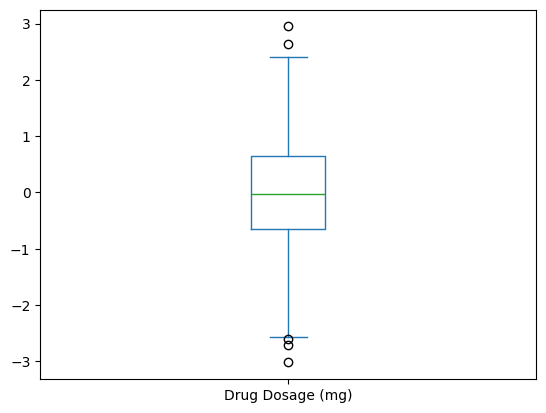

In [49]:
df['Drug Dosage (mg)'].plot(kind = 'box')

<Axes: >

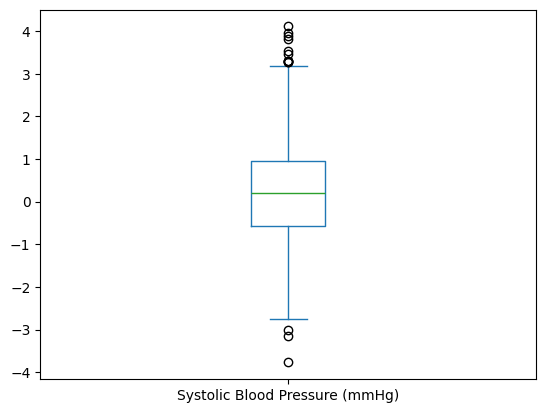

In [50]:
df['Systolic Blood Pressure (mmHg)'].plot(kind = 'box')

<Axes: >

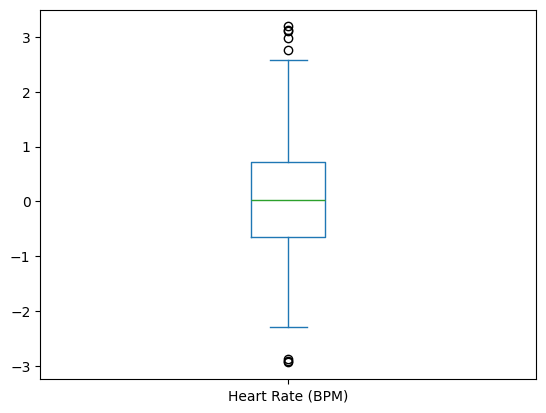

In [51]:
df['Heart Rate (BPM)'].plot(kind = 'box')

<Axes: >

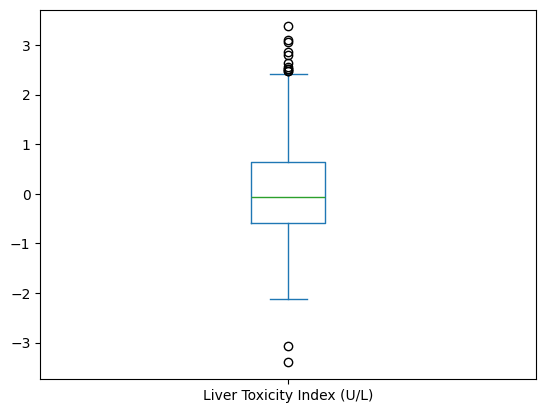

In [52]:
df['Liver Toxicity Index (U/L)'].plot(kind = 'box')

<Axes: >

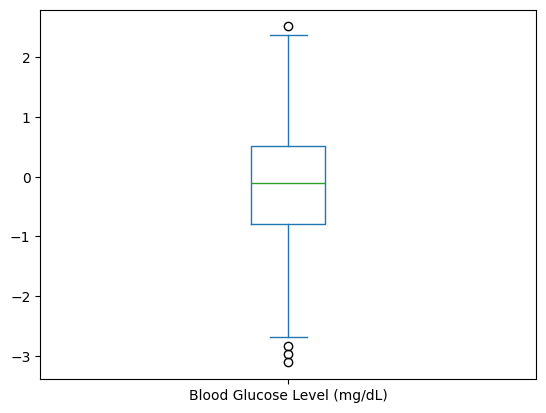

In [53]:
df['Blood Glucose Level (mg/dL)'].plot(kind = 'box')

#### Removing outliers

In [54]:
Q1 = df['Drug Dosage (mg)'].quantile(0.25)
Q3 = df['Drug Dosage (mg)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Drug Dosage (mg)'] = df['Drug Dosage (mg)'].clip(lower, upper)

<Axes: >

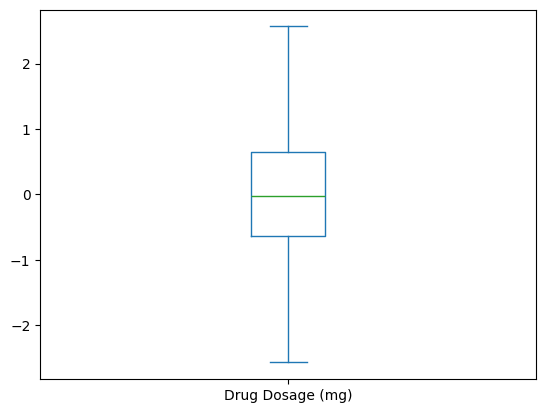

In [55]:
df['Drug Dosage (mg)'].plot(kind = 'box')

In [56]:
Q1 = df['Systolic Blood Pressure (mmHg)'].quantile(0.25)
Q3 = df['Systolic Blood Pressure (mmHg)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Systolic Blood Pressure (mmHg)'] = df['Systolic Blood Pressure (mmHg)'].clip(lower, upper)

<Axes: >

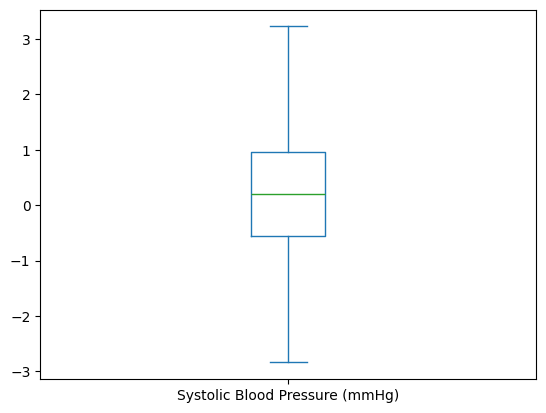

In [57]:
df['Systolic Blood Pressure (mmHg)'].plot(kind = 'box')

In [58]:
Q1 = df['Heart Rate (BPM)'].quantile(0.25)
Q3 = df['Heart Rate (BPM)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Heart Rate (BPM)'] = df['Heart Rate (BPM)'].clip(lower, upper)

<Axes: >

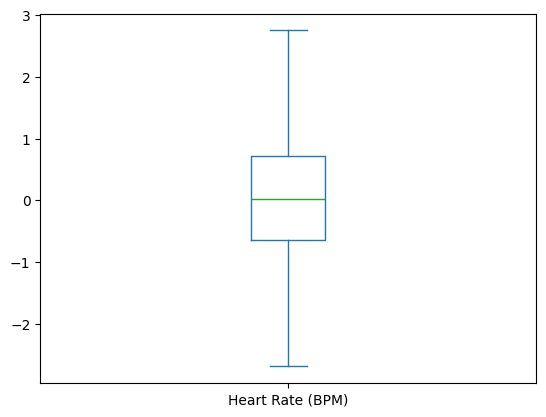

In [59]:
df['Heart Rate (BPM)'].plot(kind = 'box')

In [60]:
Q1 = df['Liver Toxicity Index (U/L)'].quantile(0.25)
Q3 = df['Liver Toxicity Index (U/L)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Liver Toxicity Index (U/L)'] = df['Liver Toxicity Index (U/L)'].clip(lower, upper)

<Axes: >

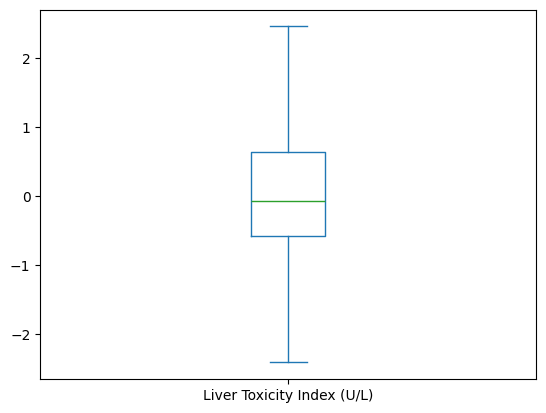

In [61]:
df['Liver Toxicity Index (U/L)'].plot(kind = 'box')

In [62]:
Q1 = df['Blood Glucose Level (mg/dL)'].quantile(0.25)
Q3 = df['Blood Glucose Level (mg/dL)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Blood Glucose Level (mg/dL)'] = df['Blood Glucose Level (mg/dL)'].clip(lower, upper)

<Axes: >

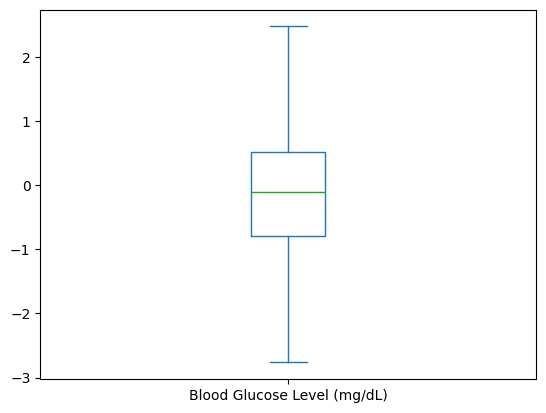

In [63]:
df['Blood Glucose Level (mg/dL)'].plot(kind = 'box')

### Kernel Density Estimation for checking frequency distribution of numerical features

<Axes: ylabel='Density'>

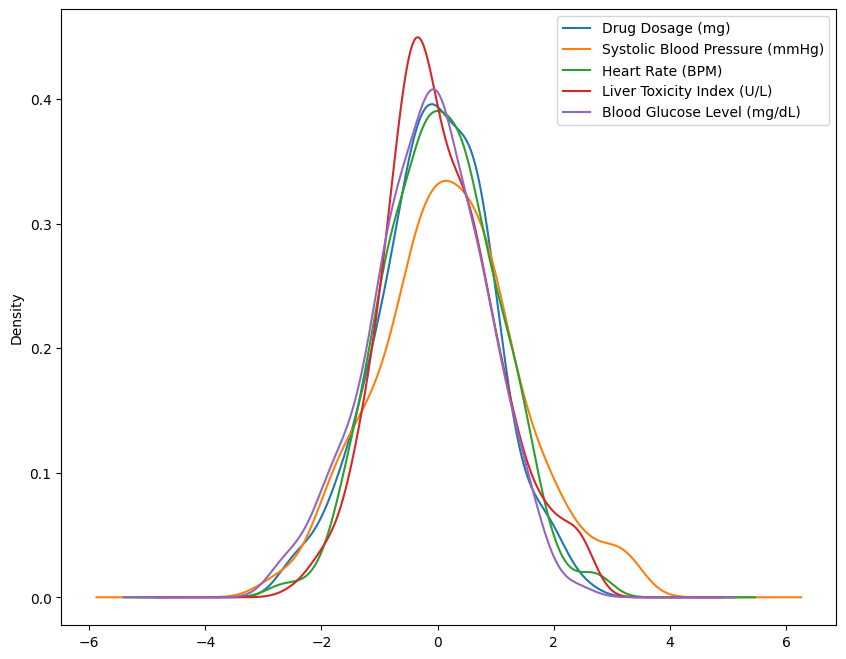

In [64]:
df.drop('Drug Response', axis = True).plot(kind = 'kde', figsize = (10, 8))

#### This visualization shows all features are normally distributed

### Heatmap to visualize correlation among features

<Axes: >

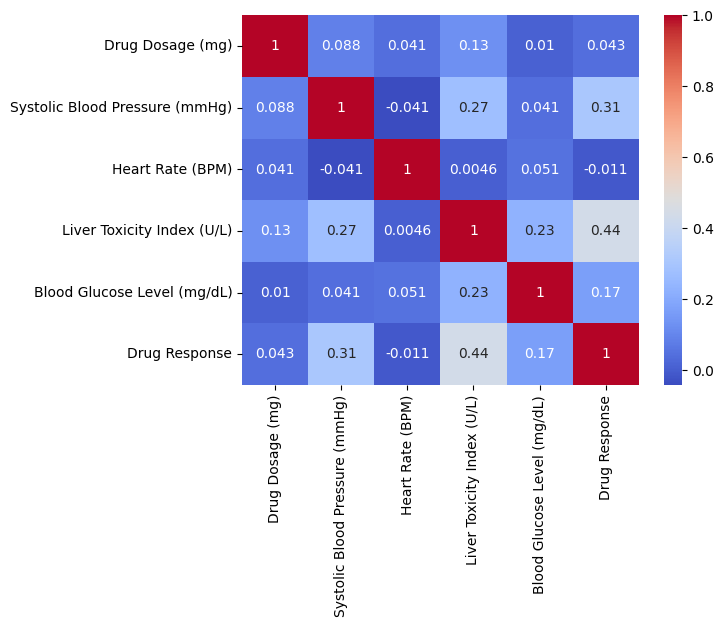

In [65]:
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')

#### no feature is having strong relation with another feature. They are not correlated

#### Dataset does not have any categorical column so no encoding is needed.

In [66]:
# Assigning variables 
X = df.drop('Drug Response', axis = 1)
y = df['Drug Response']

In [67]:
# Splitting of dataset into train and test. Taking 30% data for testing and 70% for training. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
print(X_train.shape)
print(y_train.shape)

(350, 5)
(350,)


### SVM Model Building

In [68]:
# training svm model
svm = SVC()
svm_train = svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
accuracy_score(y_pred, y_test) # accuracy score of svm

0.7933333333333333

In [69]:
### Defining SVM model with different kernels
svm_linear = SVC(kernel = 'linear', C = 1.0)
svm_poly = SVC(kernel = 'poly', degree = 3, C = 1.0)
svm_rbf = SVC(kernel = 'rbf', gamma = 0.5, C = 1.0)

In [70]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
# Training model with Linear Kernel
model_svm = svm_linear.fit(X_train_scaled, y_train)
y_pred_linear = svm_linear.predict(X_test_scaled)

In [72]:
# Training model with polynomial Kernel
model_svm = svm_poly.fit(X_train_scaled, y_train)
y_pred_poly = svm_poly.predict(X_test_scaled)

In [73]:
# Training model with rbf Kernel
model_svm = svm_rbf.fit(X_train_scaled, y_train)
y_pred_rbf = svm_rbf.predict(X_test_scaled)

### Model Evaluation

In [74]:
# Accuracy score 
accuracy_linear = accuracy_score(y_pred_linear, y_test)
accuracy_poly = accuracy_score(y_pred_poly, y_test)
accuracy_rbf = accuracy_score(y_pred_rbf, y_test)
print('Accuracy Score of Linear SVM:  ', accuracy_linear)
print('Accuracy Score of Polynomial SVM:  ', accuracy_poly)
print('Accuracy Score of RBF SVM:  ', accuracy_rbf)

Accuracy Score of Linear SVM:   0.7066666666666667
Accuracy Score of Polynomial SVM:   0.7133333333333334
Accuracy Score of RBF SVM:   0.8066666666666666


In [75]:
# precision
print("Precision Score of svm kernels")
precision_linear = precision_score(y_test, y_pred_linear)
precision_poly = precision_score(y_test, y_pred_poly)
precision_rbf = precision_score(y_test, y_pred_rbf)
print('Precision score of Linear SVM:  ', precision_linear)
print('Precision score of Polynomial SVM:  ', precision_poly)
print('Precision score of RBF SVM:  ', precision_rbf)

#Recall score
print('\n')
print("Recall Score of svm kernels")
recall_linear = recall_score(y_test, y_pred_linear)
recall_poly = recall_score(y_test, y_pred_poly)
recall_rbf = recall_score(y_test, y_pred_rbf)
print('Recall score of Linear SVM:  ', recall_linear)
print('Recall score of Polynomial SVM:  ', recall_poly)
print('Recall score of RBF SVM:  ', recall_rbf)

# F1 Score
print('\n')
print("F1 Score of svm kernels")
f1_linear = f1_score(y_test, y_pred_linear)
f1_poly = f1_score(y_test, y_pred_poly)
f1_rbf = f1_score(y_test, y_pred_rbf)
print('F1 score of Linear SVM:  ', f1_linear)
print('F1 score of Polynomial SVM:  ', f1_poly)
print('F1 score of RBF SVM:  ', f1_rbf)

Precision Score of svm kernels
Precision score of Linear SVM:   0.7846153846153846
Precision score of Polynomial SVM:   0.7714285714285715
Precision score of RBF SVM:   0.8513513513513513


Recall Score of svm kernels
Recall score of Linear SVM:   0.6296296296296297
Recall score of Polynomial SVM:   0.6666666666666666
Recall score of RBF SVM:   0.7777777777777778


F1 Score of svm kernels
F1 score of Linear SVM:   0.6986301369863014
F1 score of Polynomial SVM:   0.7152317880794702
F1 score of RBF SVM:   0.8129032258064516


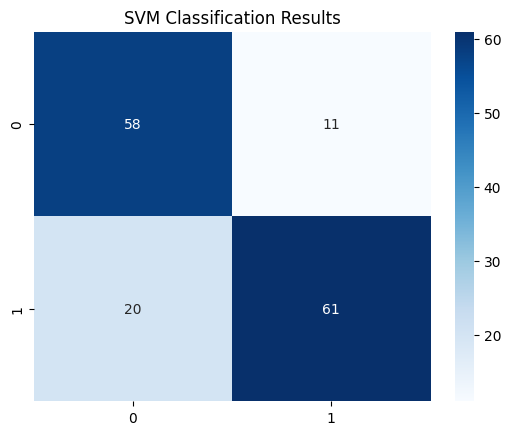

In [76]:
# classification result using confusion matrix
sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("SVM Classification Results")
plt.show()

In [77]:
# Experiment with different C values
C_values = [0.1, 1, 10, 100]
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    print(f"\nKernel: {kernel}")
    for c in C_values:
        model = SVC(kernel=kernel,C=c)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        print("C =", c,"Accuracy =", accuracy_score(y_test, pred))


Kernel: linear
C = 0.1 Accuracy = 0.7066666666666667
C = 1 Accuracy = 0.7066666666666667
C = 10 Accuracy = 0.7066666666666667
C = 100 Accuracy = 0.7066666666666667

Kernel: poly
C = 0.1 Accuracy = 0.6733333333333333
C = 1 Accuracy = 0.7133333333333334
C = 10 Accuracy = 0.7
C = 100 Accuracy = 0.68

Kernel: rbf
C = 0.1 Accuracy = 0.74
C = 1 Accuracy = 0.78
C = 10 Accuracy = 0.78
C = 100 Accuracy = 0.7466666666666667


In [78]:
# Experiment with grid search for parameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.1,1,10,100],
    'gamma':[0.01,0.1,1],
    'kernel':['linear','poly','rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_) # best parameter
print(grid.best_score_) # best accuracy

{'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
0.7428571428571429


### Compare SVM Performance with Different Kernels

In [82]:
kernels = ['linear','poly','rbf']
results = []
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results.append(acc)
    print(k, ":", acc)

linear : 0.7066666666666667
poly : 0.7133333333333334
rbf : 0.78


#### from all the above model evaluation it show that SVM works well with rbf kernel.

### Strengths of SVM

1. Works well with small and medium-sized datasets.
2. Works well when data is linearly and non-linearly separable.
3. Handles high-dimensional data efficiently.
4. Good generalization performance.

### Weaknesses of SVM

1. Training time increases for large datasets.
2. Sensitive to parameter tuning.
3. Choosing the correct kernel can be difficult.


### practical implications of SVM in real-world classification tasks
1. image classification - face recognition, object classification
2. text analytics - spam mail detection, sentiment analysis
3. Medical Diagnosis - cancer classification, drug reccumendation system, diseas diagnosis